In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
mpl.style.use('seaborn-v0_8')

In [2]:
#Read Data
df=pd.read_excel('/home/jovyan/projects/Final_Project/OpenAccessData_ChargeCollectionEfficiency_2025_ver02.ods', 
                      sheet_name='Figure 5',
                     skiprows=6,
                     usecols='B:D',
                     names=['Dose','CCE', 'Polarity'])

In [3]:
#Scale and resample
from sklearn.utils import resample
#Split and undersample low CCE
low=df[df['CCE']<0.3]
high=df[df['CCE']>=0.3]
low_resampled = resample(low, n_samples=80)
balanced=pd.concat([low_resampled, high]).reset_index(drop=True)

#Initialise Scaler
scaler= StandardScaler()
balanced_scaled=scaler.fit_transform(balanced)

#Extract Data and Scale
data=df.to_numpy()
Dose=data[:,0]
CCE=data[:,1]
Polarity=data[:,2]
print(Dose)

Dose_sc=balanced_scaled[:,0]
CCE_sc=balanced_scaled[:,1]
Polarity_sc=balanced_scaled[:,2]
print(Dose_sc)

[0.1        0.19292929 0.28585859 0.37878788 0.47171717 0.56464646
 0.65757576 0.75050505 0.84343434 0.93636364 1.02929293 1.12222222
 1.21515152 1.30808081 1.4010101  1.49393939 1.58686869 1.67979798
 1.77272727 1.86565657 1.95858586 2.05151515 2.14444444 2.23737374
 2.33030303 2.42323232 2.51616162 2.60909091 2.7020202  2.79494949
 2.88787879 2.98080808 3.07373737 3.16666667 3.25959596 3.35252525
 3.44545455 3.53838384 3.63131313 3.72424242 3.81717172 3.91010101
 4.0030303  4.0959596  4.18888889 4.28181818 4.37474747 4.46767677
 4.56060606 4.65353535 4.74646465 4.83939394 4.93232323 5.02525253
 5.11818182 5.21111111 5.3040404  5.3969697  5.48989899 5.58282828
 5.67575758 5.76868687 5.86161616 5.95454545 6.04747475 6.14040404
 6.23333333 6.32626263 6.41919192 6.51212121 6.60505051 6.6979798
 6.79090909 6.88383838 6.97676768 7.06969697 7.16262626 7.25555556
 7.34848485 7.44141414 7.53434343 7.62727273 7.72020202 7.81313131
 7.90606061 7.9989899  8.09191919 8.18484848 8.27777778 8.37070

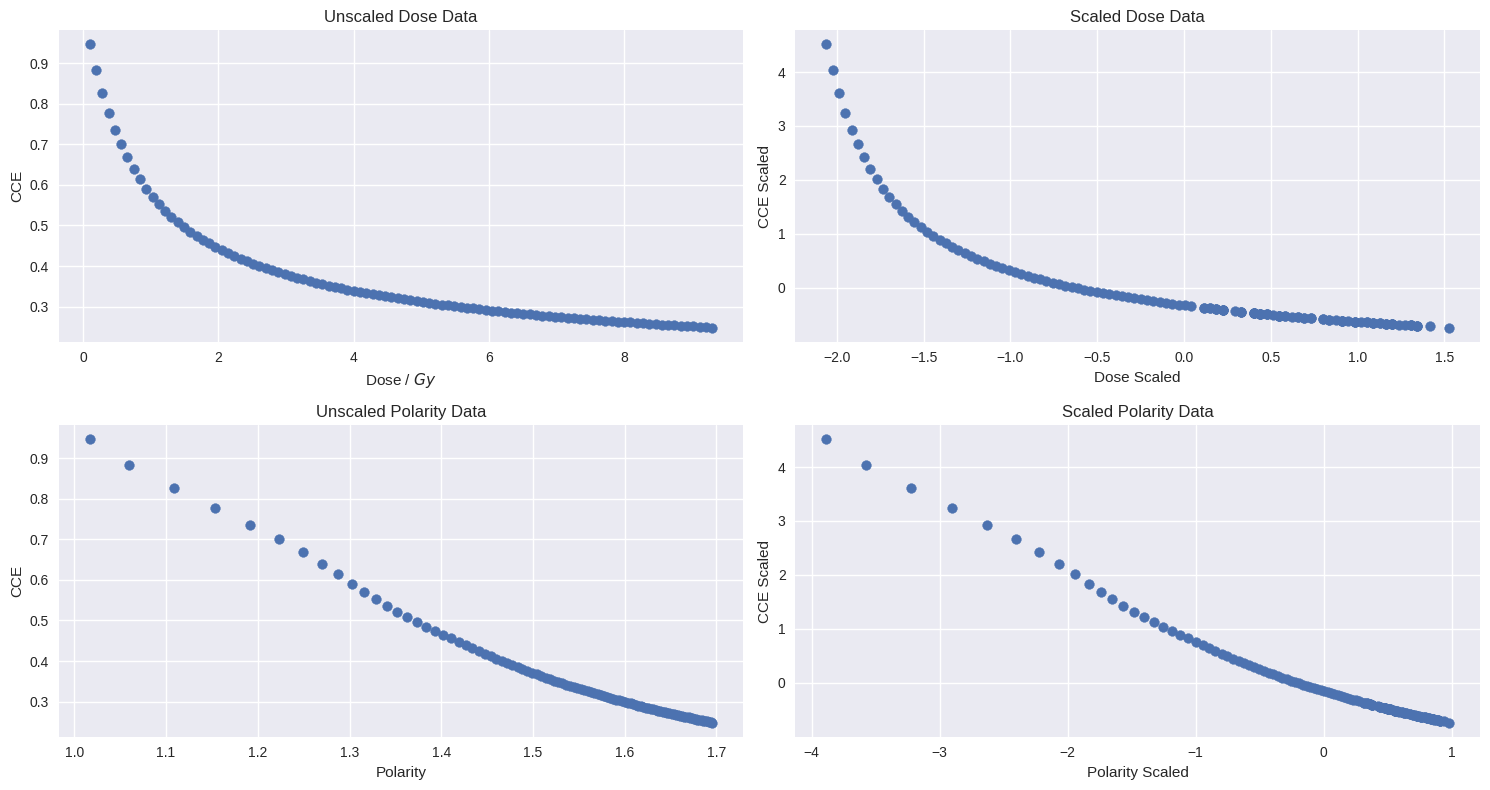

In [4]:
#Plot Data and Augmentations
#Dose Plot
plt.figure(figsize=(15,8))
plt.subplot(2,2,1)
plt.scatter(Dose, CCE)
plt.xlabel('Dose / $Gy$')
plt.ylabel('CCE')
plt.title('Unscaled Dose Data')

plt.subplot(2,2,2)
plt.scatter(Dose_sc, CCE_sc)
plt.xlabel('Dose Scaled')
plt.ylabel('CCE Scaled')
plt.title('Scaled Dose Data')

#Polarity Plot
plt.subplot(2,2,3)
plt.scatter(Polarity, CCE)
plt.xlabel('Polarity')
plt.ylabel('CCE')
plt.title('Unscaled Polarity Data')

plt.subplot(2,2,4)
plt.scatter(Polarity_sc, CCE_sc)
plt.xlabel('Polarity Scaled')
plt.ylabel('CCE Scaled')
plt.title('Scaled Polarity Data')

plt.tight_layout()
plt.savefig('Raw and Augmented Data' ,dpi=1000)

In [5]:
#Initialise Training and Test Split
from sklearn.model_selection import train_test_split
def train(seed):
    x=balanced_scaled[:,[0,2]]
    y=CCE_sc
    x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.3, shuffle=True, random_state=seed)
    return x_train, x_test, y_train, y_test

In [6]:
#Build Model
#Parameters
ValSplit=0.1
Batch=4
Nepochs=200
lr=1e-4



#Model
def build_model(seed):
    tf.random.set_seed(seed)
    #Callbacks
    early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-8)
    #Architecture
    model =tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(2,)),
        tf.keras.layers.Dense(256, activation='swish'),
        
        tf.keras.layers.Dense(64, activation='swish'),
        
        tf.keras.layers.Dense(32, activation='swish'),
        
        tf.keras.layers.Dense(1)])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    return model, early_stop, reduce_lr

#Train and Evaluate
def train_eval(x_train, y_train, x_test, y_test):
    model, early_stop, reduce_lr=build_model(seed)
    history=model.fit(x_train, y_train, epochs=Nepochs, batch_size=Batch, validation_split=ValSplit, callbacks=[early_stop, reduce_lr],verbose=0)

    preds=model.predict(x_test, verbose=0)
    y_test_rescaled=y_test*scaler.scale_[1] +scaler.mean_[1]
    preds_rescaled=preds.flatten()*scaler.scale_[1] +scaler.mean_[1]
    mae=np.mean(np.abs(y_test_rescaled-preds_rescaled))
    return model, mae, x_test, y_test, history
#Append Results 
results=[]
for seed in range(50):
    x_train, x_test, y_train, y_test=train(seed)
    results.append(train_eval(x_train, y_train, x_test, y_test))
maes=[i[1] for i in results]
print(f"MAE: {np.mean(maes)*100:.3f}% +- {np.std(maes)*100:.3f}%")



/opt/conda/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[HAMI-core Msg(3812465:139642473307456:libvgpu.c:839)]: Initializing.....
[HAMI-core Warn(3812465:139642473307456:multiprocess_memory_limit.c:548)]: Kick dead proc 2237953
[HAMI-core Msg(3812465:139642473307456:libvgpu.c:855)]: Initialized
I0000 00:00:1776078126.153175 3812465 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5874 MB memory:  -> device: 0, name: NVIDIA H200 NVL, pci bus id: 0000:c7:00.0, compute capability: 9.0
I0000 00:00:1776078128.526975 3813405 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


MAE: 1.184% +- 1.346%


In [8]:
#Get Best Model
best=np.argmin(maes)
best_model, best_mae, best_x_test, best_y_test, best_history = results[best]

  N(Epochs)        =  200


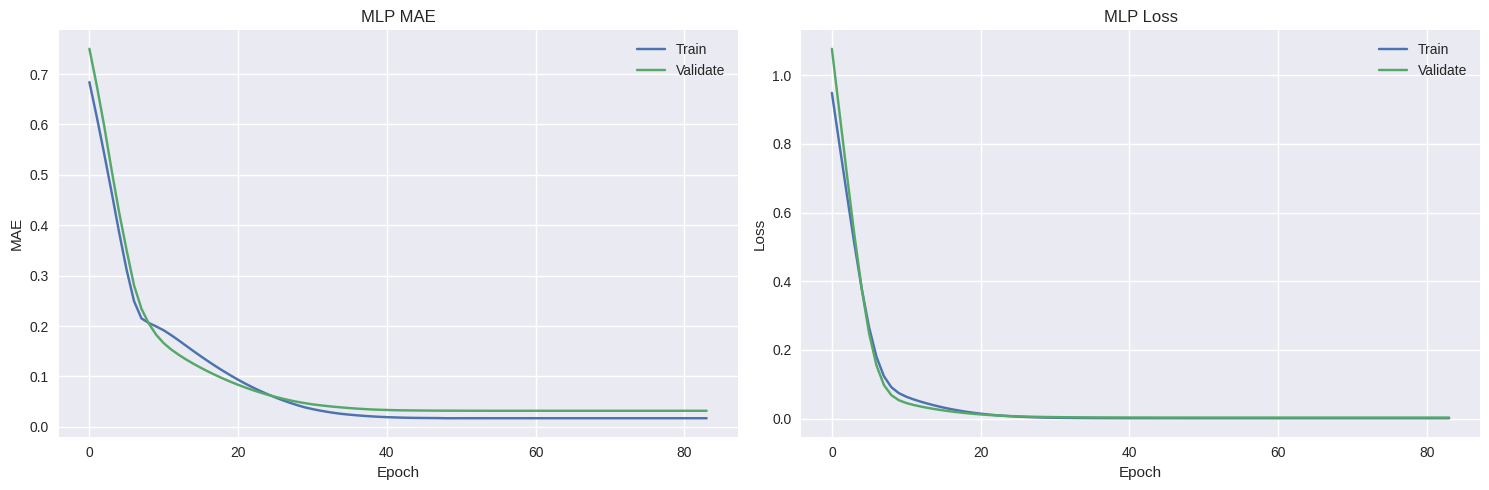

In [9]:
#Training History
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)

#MAE Plot
plt.plot(best_history.history['mae'])
plt.plot(best_history.history['val_mae'])
plt.title('MLP MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validate'], loc='upper right')


print("  N(Epochs)        = ", Nepochs)


#Loss Plot
plt.subplot(1,2,2)
plt.plot(best_history.history['loss']) # 'loss'
plt.plot(best_history.history['val_loss']) # 'val_loss'
plt.title('MLP Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validate'], loc='upper right')
plt.tight_layout()
 
plt.savefig('Training Data', dpi=1000)

In [10]:
#Get Prediction and rescale, calculate residuals
best_preds=best_model.predict(best_x_test)

#Rescale
y_test_rescaled=best_y_test*scaler.scale_[1] +scaler.mean_[1]
preds_rescaled=best_preds.flatten()*scaler.scale_[1] +scaler.mean_[1]
x_dose_rescaled=best_x_test*scaler.scale_[0] +scaler.mean_[0]
x_pol_rescaled=best_x_test*scaler.scale_[2] +scaler.mean_[2]
print(f"Mean Absolute Error: {np.mean(np.abs(y_test_rescaled-preds_rescaled)):.4f}")

#Residuals
residuals=y_test_rescaled-preds_rescaled

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Mean Absolute Error: 0.0019


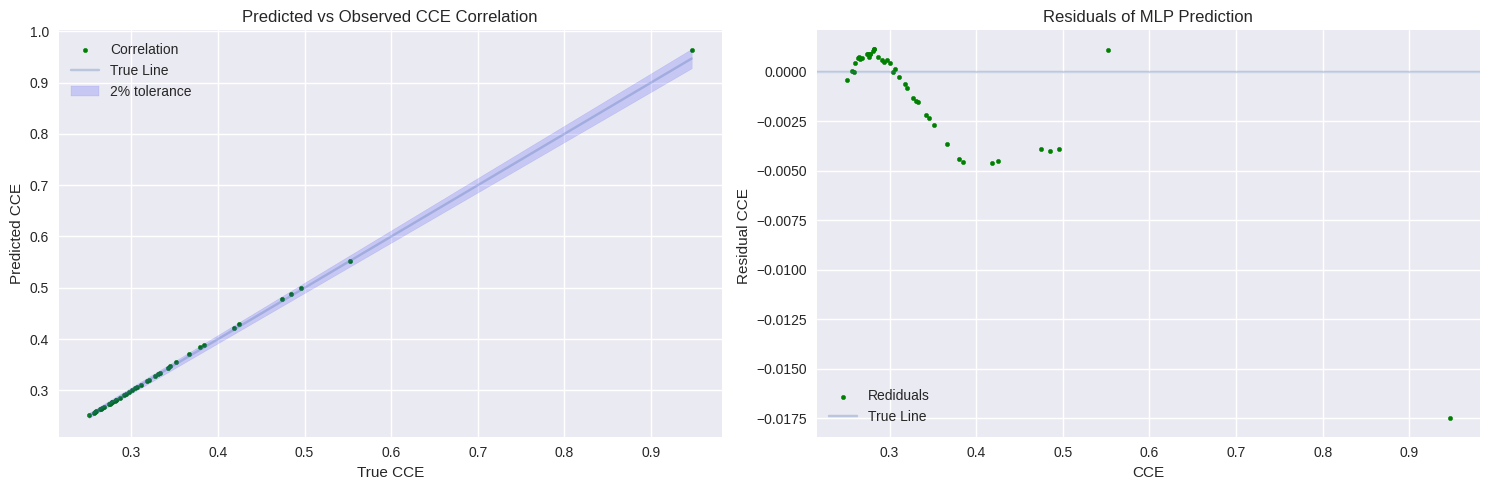

In [11]:
#Plot Evaluation
plt.figure(figsize=(15,5))

#Correlation Plot
plt.subplot(1,2,1)
plt.scatter(y_test_rescaled,preds_rescaled, color='green', s=10, label='Correlation')
straight=np.linspace(y_test_rescaled.min(), y_test_rescaled.max())
plt.plot(straight, straight,label='True Line',  alpha=0.3)
plt.fill_between(straight, straight*0.98, straight*1.02, alpha=0.15, color='b', label='2% tolerance')

plt.title('Predicted vs Observed CCE Correlation')
plt.xlabel('True CCE' ), 
plt.ylabel('Predicted CCE')
plt.legend()

#Residuals Plot
plt.subplot(1,2,2)
plt.scatter(y_test_rescaled, residuals, color='green',  s=10, label='Rediduals')
plt.axhline(y=0, label='True Line',alpha=0.3)

plt.title('Residuals of MLP Prediction')
plt.xlabel('CCE')
plt.ylabel('Residual CCE ')
plt.legend()

plt.tight_layout()
plt.savefig('Model Evaluation', dpi=1000)

In [12]:
#Error Interval
errors=np.abs(y_test_rescaled -preds_rescaled)/y_test_rescaled*100
for t in [0.1, 0.5, 1, 2, 3]:
    print(f"Within {t}%: {(errors<t).mean()*100:.1f}%")

Within 0.1%: 11.9%
Within 0.5%: 71.4%
Within 1%: 88.1%
Within 2%: 100.0%
Within 3%: 100.0%


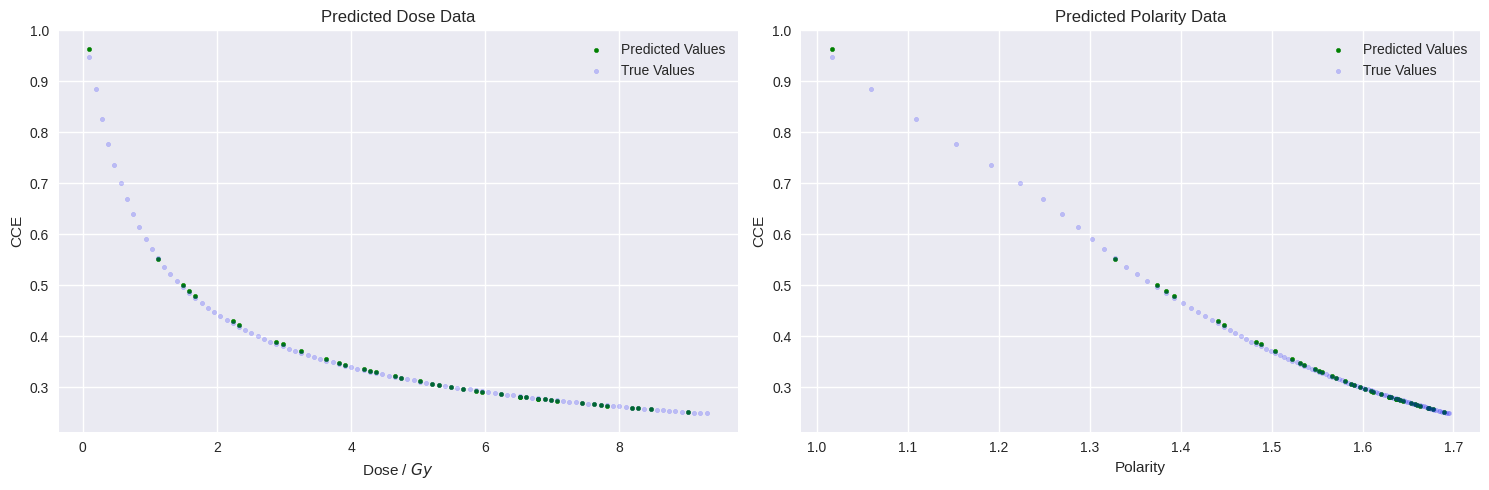

In [13]:
#Plot Prediction

#Dose Prediction
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.scatter(x_dose_rescaled[:,0], preds_rescaled, s=10, label='Predicted Values', color='g')
plt.scatter(Dose, CCE, color='b', alpha=0.2, s=10, label='True Values')
plt.xlabel('Dose / $Gy$')
plt.ylabel('CCE')
plt.title('Predicted Dose Data')
plt.legend()

#Polarity Prediction
plt.subplot(1,2,2)
plt.scatter(x_pol_rescaled[:,1], preds_rescaled, s=10, label='Predicted Values', color='g')
plt.scatter(Polarity, CCE, color='b', alpha=0.2, s=10, label='True Values')
plt.xlabel('Polarity')
plt.ylabel('CCE')
plt.title('Predicted Polarity Data')
plt.legend()

plt.tight_layout()
plt.savefig('Predictions', dpi=1000)